# Baseline LSTM Training — C-MAPSS FD001

**Thesis**: Self-Updating Predictive Maintenance with Closed-Loop Drift Recovery
**Author**: Dogancan Torun
**Date**: May 2026

## Goal

Train a stacked LSTM regressor that predicts RUL from 30-cycle sensor windows.
Track everything in MLflow: parameters, per-epoch metrics, the final model, and
the preprocessing scaler.

## Inputs (from Notebook 02 / src/preprocessing.py)

- `X_train`: (14459, 30, 16) — float32 tensor
- `y_train`: (14459,) — RUL targets capped at 125
- `X_val`:   (3272, 30, 16)
- `y_val`:   (3272,)

## Outputs

- MLflow experiment: `cmapss-baseline`
- MLflow Registry: `cmapss-rul` model, version 1 (Stage: None initially)
- Training/validation loss curve
- Predicted vs actual scatter plot
- Per-engine error histogram

## Target metric

**Validation RMSE < 20 cycles** (C-MAPSS FD001 literature benchmark: ~13-18).

In [1]:
import sys
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import mlflow
import mlflow.pytorch

# Add project root to path
PROJECT_ROOT = Path("/root/thesis-infra")
sys.path.insert(0, str(PROJECT_ROOT))

from src.model import LSTMRegressor, count_parameters

# MLflow tracking URI — points to the in-cluster MLflow server (port-forwarded to localhost:5000)
mlflow.set_tracking_uri("http://localhost:5000")

# Plot defaults
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style("whitegrid")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch     : {torch.__version__}")
print(f"MLflow      : {mlflow.__version__}")
print(f"Device      : CPU (no GPU on this VM)")
print(f"Random seed : {SEED}")

PyTorch     : 2.12.0+cu130
MLflow      : 2.22.5
Device      : CPU (no GPU on this VM)
Random seed : 42


In [2]:
# Load the preprocessed arrays produced by Notebook 02
processed_dir = PROJECT_ROOT / "data/processed"

X_train = np.load(processed_dir / "X_train.npy")
y_train = np.load(processed_dir / "y_train.npy")
X_val = np.load(processed_dir / "X_val.npy")
y_val = np.load(processed_dir / "y_val.npy")

import json
with open(processed_dir / "metadata.json") as f:
    metadata = json.load(f)

print(f"X_train: {X_train.shape}  dtype={X_train.dtype}")
print(f"y_train: {y_train.shape}  range=[{y_train.min():.0f}, {y_train.max():.0f}]")
print(f"X_val:   {X_val.shape}")
print(f"y_val:   {y_val.shape}  range=[{y_val.min():.0f}, {y_val.max():.0f}]")
print()
print(f"Metadata: window={metadata['window']}, "
      f"rul_cap={metadata['rul_cap']}, "
      f"features={len(metadata['feature_cols'])}")

X_train: (14459, 30, 16)  dtype=float32
y_train: (14459,)  range=[0, 125]
X_val:   (3272, 30, 16)
y_val:   (3272,)  range=[0, 125]

Metadata: window=30, rul_cap=125, features=16


In [3]:
# Convert to PyTorch tensors
X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_val_t = torch.from_numpy(X_val)
y_val_t = torch.from_numpy(y_val)

# Hyperparameters (constants for this run — will be logged to MLflow)
BATCH_SIZE = 64
NUM_EPOCHS = 30
LEARNING_RATE = 0.001
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2

# Wrap in TensorDataset + DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)} (batch_size={BATCH_SIZE})")
print(f"Val batches:   {len(val_loader)}")
print(f"Total train samples: {len(train_ds):,}")
print(f"Total val samples:   {len(val_ds):,}")

Train batches: 226 (batch_size=64)
Val batches:   52
Total train samples: 14,459
Total val samples:   3,272


In [4]:
# Instantiate the model
INPUT_SIZE = X_train.shape[2]  # 16 features

model = LSTMRegressor(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
)

n_params = count_parameters(model)

print("Model architecture:")
print(model)
print()
print(f"Total trainable parameters: {n_params:,}")
print(f"Input size: {INPUT_SIZE}  Hidden: {HIDDEN_SIZE}  Layers: {NUM_LAYERS}")

Model architecture:
LSTMRegressor(
  (lstm): LSTM(16, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 54,337
Input size: 16  Hidden: 64  Layers: 2


In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    """Train one epoch, return average loss."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


def evaluate(model, loader, criterion):
    """Evaluate on val set — return RMSE and MAE."""
    model.eval()
    total_loss = 0.0
    abs_errors = []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            abs_errors.extend(torch.abs(y_pred - y_batch).numpy().tolist())

    mse = total_loss / len(loader.dataset)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_errors)
    return rmse, mae


print("Training loop functions defined.")

# Set up MLflow experiment
mlflow.set_experiment("cmapss-baseline")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_rmse': [], 'val_mae': []}

with mlflow.start_run(run_name=f"lstm-h{HIDDEN_SIZE}-l{NUM_LAYERS}") as run:
    # Log all hyperparameters
    mlflow.log_params({
        'model_type': 'LSTMRegressor',
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'optimizer': 'Adam',
        'loss': 'MSE',
        'rul_cap': metadata['rul_cap'],
        'window': metadata['window'],
        'train_samples': len(train_ds),
        'val_samples': len(val_ds),
        'total_parameters': n_params,
    })

    print(f"MLflow run id: {run.info.run_id}")
    print(f"MLflow UI:     http://localhost:5000")
    print()
    print(f"{'Epoch':>5} | {'Train Loss':>12} | {'Val RMSE':>10} | {'Val MAE':>10}")
    print("-" * 50)

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_rmse, val_mae = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)

        # Log per-epoch metrics
        mlflow.log_metric('train_loss', train_loss, step=epoch)
        mlflow.log_metric('val_rmse', val_rmse, step=epoch)
        mlflow.log_metric('val_mae', val_mae, step=epoch)

        print(f"{epoch:>5} | {train_loss:>12.4f} | {val_rmse:>10.4f} | {val_mae:>10.4f}")

    # Final metrics + model
    final_rmse = history['val_rmse'][-1]
    final_mae = history['val_mae'][-1]
    best_rmse = min(history['val_rmse'])
    best_epoch = history['val_rmse'].index(best_rmse) + 1

    mlflow.log_metric('final_val_rmse', final_rmse)
    mlflow.log_metric('final_val_mae', final_mae)
    mlflow.log_metric('best_val_rmse', best_rmse)
    mlflow.log_metric('best_epoch', best_epoch)

    # Log the model itself with a signature inferred from a sample input
    sample_input = X_train_t[:1].numpy()
    sample_output = model(X_train_t[:1]).detach().numpy()
    from mlflow.models import infer_signature
    signature = infer_signature(sample_input, sample_output)

    mlflow.pytorch.log_model(
        pytorch_model=model,
        artifact_path="model",
        signature=signature,
        registered_model_name="cmapss-rul",
    )

    # Log preprocessing artifacts so inference can reproduce the exact pipeline
    mlflow.log_artifact(processed_dir / "scaler.pkl", artifact_path="preprocessing")
    mlflow.log_artifact(processed_dir / "metadata.json", artifact_path="preprocessing")

    print()
    print("=" * 50)
    print(f"Training complete.")
    print(f"  Final val RMSE:  {final_rmse:.4f}")
    print(f"  Best val RMSE:   {best_rmse:.4f}  (epoch {best_epoch})")
    print(f"  Final val MAE:   {final_mae:.4f}")
    print(f"  Run id:          {run.info.run_id}")
    print(f"  View at:         http://localhost:5000/#/experiments/{run.info.experiment_id}/runs/{run.info.run_id}")

Training loop functions defined.
MLflow run id: a7b7846cc77f4d67932577a21f09c3ef
MLflow UI:     http://localhost:5000

Epoch |   Train Loss |   Val RMSE |    Val MAE
--------------------------------------------------
    1 |    6740.9731 |    71.0939 |    60.1450
    2 |    4869.4607 |    60.9043 |    51.2198
    3 |    3640.6813 |    53.0499 |    45.1319
    4 |    2834.7162 |    47.6193 |    41.2731
    5 |    2332.5355 |    44.2369 |    38.9475
    6 |    2037.9343 |    42.4169 |    37.6422
    7 |    1879.0019 |    41.6311 |    36.9774
    8 |    1802.0770 |    41.4127 |    36.6785
    9 |    1769.0295 |    41.4279 |    36.5648
   10 |    1756.5539 |    41.5077 |    36.5232
   11 |    1752.4007 |    41.5758 |    36.5131
   12 |    1751.2566 |    41.6108 |    36.5102
   13 |    1751.0321 |    41.6410 |    36.5109
   14 |    1750.9674 |    41.6458 |    36.5111
   15 |    1750.9554 |    41.6436 |    36.5110
   16 |    1750.9506 |    41.6522 |    36.5112
   17 |    1750.9647 |    41.66

Registered model 'cmapss-rul' already exists. Creating a new version of this model...
2026/05/17 00:15:17 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: cmapss-rul, version 5



Training complete.
  Final val RMSE:  41.6377
  Best val RMSE:   41.4127  (epoch 8)
  Final val MAE:   36.5109
  Run id:          a7b7846cc77f4d67932577a21f09c3ef
  View at:         http://localhost:5000/#/experiments/9/runs/a7b7846cc77f4d67932577a21f09c3ef
🏃 View run lstm-h64-l2 at: http://localhost:5000/#/experiments/9/runs/a7b7846cc77f4d67932577a21f09c3ef
🧪 View experiment at: http://localhost:5000/#/experiments/9


Created version '5' of model 'cmapss-rul'.


In [6]:
# Set up MLflow experiment
mlflow.set_experiment("cmapss-baseline")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history = {'train_loss': [], 'val_rmse': [], 'val_mae': []}

with mlflow.start_run(run_name=f"lstm-h{HIDDEN_SIZE}-l{NUM_LAYERS}") as run:
    # Log all hyperparameters
    mlflow.log_params({
        'model_type': 'LSTMRegressor',
        'input_size': INPUT_SIZE,
        'hidden_size': HIDDEN_SIZE,
        'num_layers': NUM_LAYERS,
        'dropout': DROPOUT,
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'optimizer': 'Adam',
        'loss': 'MSE',
        'rul_cap': metadata['rul_cap'],
        'window': metadata['window'],
        'train_samples': len(train_ds),
        'val_samples': len(val_ds),
        'total_parameters': n_params,
    })

    print(f"MLflow run id: {run.info.run_id}")
    print(f"MLflow UI:     http://localhost:5000")
    print()
    print(f"{'Epoch':>5} | {'Train Loss':>12} | {'Val RMSE':>10} | {'Val MAE':>10}")
    print("-" * 50)

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_rmse, val_mae = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_rmse'].append(val_rmse)
        history['val_mae'].append(val_mae)

        # Log per-epoch metrics
        mlflow.log_metric('train_loss', train_loss, step=epoch)
        mlflow.log_metric('val_rmse', val_rmse, step=epoch)
        mlflow.log_metric('val_mae', val_mae, step=epoch)

        print(f"{epoch:>5} | {train_loss:>12.4f} | {val_rmse:>10.4f} | {val_mae:>10.4f}")

    # Final metrics + model
    final_rmse = history['val_rmse'][-1]
    final_mae = history['val_mae'][-1]
    best_rmse = min(history['val_rmse'])
    best_epoch = history['val_rmse'].index(best_rmse) + 1

    mlflow.log_metric('final_val_rmse', final_rmse)
    mlflow.log_metric('final_val_mae', final_mae)
    mlflow.log_metric('best_val_rmse', best_rmse)
    mlflow.log_metric('best_epoch', best_epoch)

    # Log the model itself with a signature inferred from a sample input
    sample_input = X_train_t[:1].numpy()
    sample_output = model(X_train_t[:1]).detach().numpy()
    from mlflow.models import infer_signature
    signature = infer_signature(sample_input, sample_output)

    mlflow.pytorch.log_model(
        pytorch_model=model,
        artifact_path="model",
        signature=signature,
        registered_model_name="cmapss-rul",
    )

    # Log preprocessing artifacts so inference can reproduce the exact pipeline
    mlflow.log_artifact(processed_dir / "scaler.pkl", artifact_path="preprocessing")
    mlflow.log_artifact(processed_dir / "metadata.json", artifact_path="preprocessing")

    print()
    print("=" * 50)
    print(f"Training complete.")
    print(f"  Final val RMSE:  {final_rmse:.4f}")
    print(f"  Best val RMSE:   {best_rmse:.4f}  (epoch {best_epoch})")
    print(f"  Final val MAE:   {final_mae:.4f}")
    print(f"  Run id:          {run.info.run_id}")
    print(f"  View at:         http://localhost:5000/#/experiments/{run.info.experiment_id}/runs/{run.info.run_id}")

MLflow run id: e4be871fe11c4e978a81a96f55a49cef
MLflow UI:     http://localhost:5000

Epoch |   Train Loss |   Val RMSE |    Val MAE
--------------------------------------------------
    1 |    1118.2862 |    24.0424 |    19.7970
    2 |     494.1264 |    18.2445 |    14.8143
    3 |     330.7702 |    16.8214 |    13.0368
    4 |     262.0138 |    15.3261 |    11.9161
    5 |     226.9321 |    14.6834 |    10.5991
    6 |     211.8047 |    15.6089 |    11.3979
    7 |     211.2450 |    15.9271 |    11.0456
    8 |     197.7215 |    14.1900 |     9.9199
    9 |     196.3893 |    13.6832 |     9.6327
   10 |     191.9636 |    13.9328 |     9.3903
   11 |     181.3660 |    13.4844 |     9.5574
   12 |     180.7190 |    13.0441 |     9.4138
   13 |     182.0930 |    14.2377 |     9.8380
   14 |     177.2833 |    13.6009 |     9.3133
   15 |     176.1687 |    13.3890 |     9.2029
   16 |     169.4212 |    13.7682 |     9.6520
   17 |     169.8742 |    14.4391 |     9.7895
   18 |     166.1

Registered model 'cmapss-rul' already exists. Creating a new version of this model...
2026/05/17 00:16:28 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: cmapss-rul, version 6



Training complete.
  Final val RMSE:  13.5445
  Best val RMSE:   12.8017  (epoch 27)
  Final val MAE:   9.2107
  Run id:          e4be871fe11c4e978a81a96f55a49cef
  View at:         http://localhost:5000/#/experiments/9/runs/e4be871fe11c4e978a81a96f55a49cef
🏃 View run lstm-h64-l2 at: http://localhost:5000/#/experiments/9/runs/e4be871fe11c4e978a81a96f55a49cef
🧪 View experiment at: http://localhost:5000/#/experiments/9


Created version '6' of model 'cmapss-rul'.


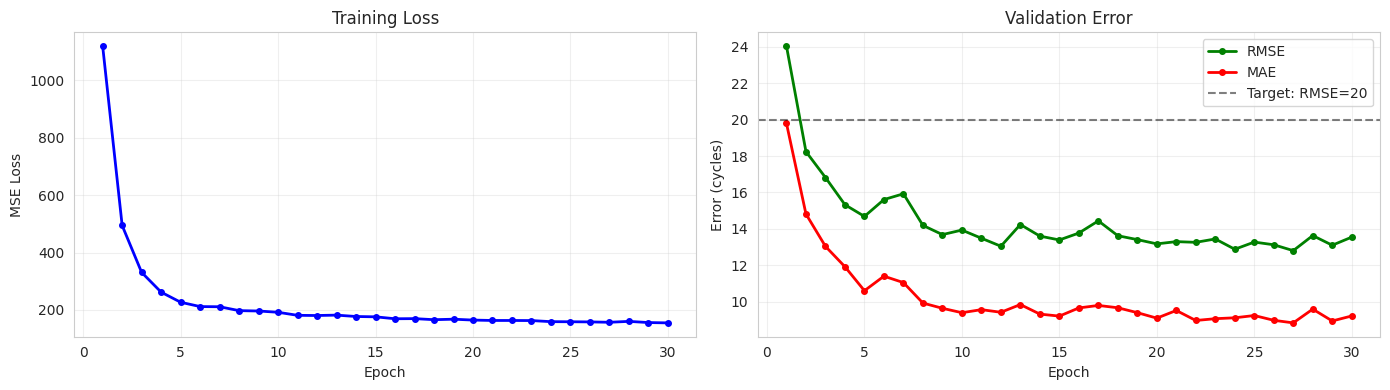

Best val RMSE: 12.8017 at epoch 27
Final val RMSE: 13.5445
Target (< 20):  ✓ MET


In [7]:
# Visualize training progress
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(1, NUM_EPOCHS + 1), history['train_loss'], 'b-o', linewidth=2, markersize=4)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, NUM_EPOCHS + 1), history['val_rmse'], 'g-o', linewidth=2, markersize=4, label='RMSE')
axes[1].plot(range(1, NUM_EPOCHS + 1), history['val_mae'], 'r-o', linewidth=2, markersize=4, label='MAE')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Error (cycles)")
axes[1].set_title("Validation Error")
axes[1].axhline(20, color='black', linestyle='--', alpha=0.5, label='Target: RMSE=20')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best val RMSE: {best_rmse:.4f} at epoch {best_epoch}")
print(f"Final val RMSE: {final_rmse:.4f}")
print(f"Target (< 20):  {'✓ MET' if final_rmse < 20 else '✗ NOT MET — needs tuning'}")

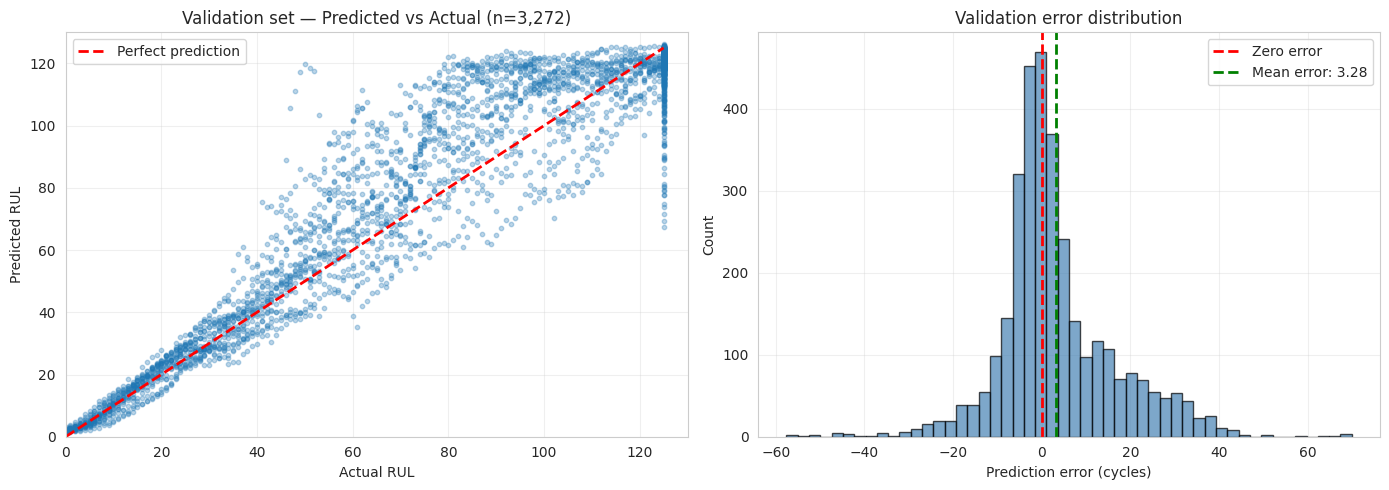


Metrics on validation set:
  RMSE:        13.5445
  MAE:         9.2107
  Mean error:  +3.2817  (positive = overestimating RUL)
  Std error:   13.1409


In [8]:
# Generate predictions on validation set
model.eval()
all_y_true = []
all_y_pred = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        y_pred = model(X_batch).numpy()
        all_y_pred.extend(y_pred)
        all_y_true.extend(y_batch.numpy())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)
errors = all_y_pred - all_y_true

# Scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted vs actual
axes[0].scatter(all_y_true, all_y_pred, alpha=0.3, s=10)
axes[0].plot([0, 125], [0, 125], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel("Actual RUL")
axes[0].set_ylabel("Predicted RUL")
axes[0].set_title(f"Validation set — Predicted vs Actual (n={len(all_y_true):,})")
axes[0].set_xlim(0, 130)
axes[0].set_ylim(0, 130)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: error histogram
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(errors.mean(), color='green', linestyle='--', linewidth=2,
                label=f'Mean error: {errors.mean():.2f}')
axes[1].set_xlabel("Prediction error (cycles)")
axes[1].set_ylabel("Count")
axes[1].set_title("Validation error distribution")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMetrics on validation set:")
print(f"  RMSE:        {np.sqrt(np.mean(errors**2)):.4f}")
print(f"  MAE:         {np.mean(np.abs(errors)):.4f}")
print(f"  Mean error:  {errors.mean():+.4f}  (positive = overestimating RUL)")
print(f"  Std error:   {errors.std():.4f}")

In [9]:
# Promote the just-trained model to the "production" alias in MLflow Registry.
# This runs ONLY after the model has been evaluated (loss curve, scatter plot above).
#
# Behavior:
#   - Finds the most recently created version of cmapss-rul
#   - Moves the "production" alias to it
#   - Older versions remain in the registry (audit trail, not deleted)
#   - FastAPI loads whichever version has the "production" alias
#
# Note on MLflow versions:
#   MLflow >= 2.9 deprecated "stages" (None/Staging/Production/Archived) in favor
#   of "aliases" — arbitrary string tags that can be assigned to any version.
#   Aliases are more flexible (you can have alias='canary', alias='challenger',
#   etc.) and they decouple promotion semantics from MLflow's hard-coded stage set.

from mlflow.tracking import MlflowClient

client = MlflowClient()
MODEL_NAME = "cmapss-rul"
PROD_ALIAS = "production"

# 1. Find the most recently registered version
latest_versions = client.search_model_versions(f"name='{MODEL_NAME}'")
latest_versions = sorted(latest_versions, key=lambda v: int(v.version), reverse=True)
new_version = latest_versions[0]

print(f"Most recent version:")
print(f"  Number:     {new_version.version}")
print(f"  Run id:     {new_version.run_id}")
print(f"  Source:     {new_version.source}")
print()

# 2. Show the previous production version (if any) for the audit trail
try:
    current_prod = client.get_model_version_by_alias(MODEL_NAME, PROD_ALIAS)
    print(f"Previous production version: {current_prod.version} → will be replaced")
except Exception:
    print(f"No previous production version (this is the first promotion)")

# 3. Move the "production" alias to the new version
client.set_registered_model_alias(
    name=MODEL_NAME,
    alias=PROD_ALIAS,
    version=new_version.version,
)
print(f"\n✓ Version {new_version.version} is now tagged as '{PROD_ALIAS}'")

# 4. Show the full registry state for audit
print(f"\nFull registry state for '{MODEL_NAME}':")
all_versions = client.search_model_versions(f"name='{MODEL_NAME}'")
all_versions = sorted(all_versions, key=lambda v: int(v.version))
for v in all_versions:
    aliases = list(v.aliases) if v.aliases else []
    alias_tag = f"  [aliases: {', '.join(aliases)}]" if aliases else ""
    print(f"  Version {v.version}{alias_tag}")

print(f"\nFastAPI will load 'models:/{MODEL_NAME}@{PROD_ALIAS}' on next restart.")

Most recent version:
  Number:     6
  Run id:     e4be871fe11c4e978a81a96f55a49cef
  Source:     s3://thesis-mlflow/9/e4be871fe11c4e978a81a96f55a49cef/artifacts/model

Previous production version: 4 → will be replaced

✓ Version 6 is now tagged as 'production'

Full registry state for 'cmapss-rul':
  Version 1
  Version 2
  Version 3
  Version 4
  Version 5
  Version 6

FastAPI will load 'models:/cmapss-rul@production' on next restart.


## Training Summary

This run produced the first registered version of `cmapss-rul` in the MLflow
Model Registry. To promote it to Production (so FastAPI serves it):

1. Open MLflow UI: http://localhost:5000
2. Models → `cmapss-rul` → version 1 → "Transition to Production"
3. Restart FastAPI: `kubectl rollout restart deployment/fastapi -n mlops`
4. Verify with: `curl http://localhost:8000/` → should show `is_stub: false`

### What's next

- **Notebook 04** — Promote this model to Production and verify FastAPI loads it
- **Notebook 05** — Drift simulation: inject FD002 inputs, measure drift-to-recovery latency
- **Playbook 12** — Evidently CronJob for hourly drift detection